In [ ]:
import torch
import gc
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, precision_recall_fscore_support, confusion_matrix
import re
import unicodedata
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, pipeline
import os
from datasets import Dataset
import torch
import warnings
warnings.filterwarnings('ignore')
import transformers

In [ ]:
!git clone https://github.com/gefero/factor_data_tuto_NLP_SICSS.git

Cloning into 'factor_data_tuto_NLP_SICSS'...
remote: Enumerating objects: 29, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 29 (delta 1), reused 14 (delta 1), pack-reused 15 (from 1)
Receiving objects: 100% (29/29), 60.05 MiB | 17.17 MiB/s, done.
Resolving deltas: 100% (3/3), done.



  <img src="https://github.com/gefero/factor_data_tuto_NLP_SICSS/blob/main/imgs/logo_final_conjunto.png?raw=true" width="80%">


# Summer Institute in Computational Social Sciences - Buenos Aires 2026
# Taller: Procesamiento de Lenguaje Natural y polarización
# Transformers


# Introducción
Este notebook explora el uso de Transformers de Hugging Face para el análisis de sentimientos. Cubriremos la carga de modelos pre-entrenados, el preprocesamiento de datos, la implementación de pipelines de clasificación y una introducción al fine-tuning.

## ¿Qué es un transformer?
Un **transformer** es un tipo de modelo de machine learning diseñado para trabajar con datos secuenciales, como texto, pero con una capacidad mucho mayor que los modelos tradicionales. Su diseño resuelve algunos de los problemas que tenían métodos previos, como los modelos recurrentes (**RNNs**) o las redes LSTM.

Los transformers son la base de los modelos de lenguaje más avanzados, como los LLMs (e.g., ChatGPT).

Cuando trabajamos con texto, queremos que el modelo entienda:
1. **El contexto**: La relación entre las palabras dentro de una frase.
2. **La relevancia de cada palabra**: No todas las palabras tienen el mismo peso en el significado.

Por ejemplo, en la frase:

> "El perro no jugó con el niño porque él tenía pulgas."

Hay cierta ambigüedad: ¿a quién se refiere "él"? ¿Al perro o al niño? El **self-attention** ayuda al modelo a desambiguar estas relaciones analizando cómo cada palabra interactúa con las demás.
  
Modelos previos, como las RNNs, procesaban las palabras una por una, pero olvidaban información a medida que avanzaban. Además, eran lentos y no podían mirar toda la frase al mismo tiempo.

### ¿Cómo funcionan los transformers?
Los transformers usan un mecanismo clave llamado **"atención"**, específicamente el **mecanismo de atención autoconsciente** (**self-attention**). Este mecanismo les permite:

1. **Mirar todas las palabras al mismo tiempo** (paralelismo).
2. **Decidir cuáles palabras son más importantes para entender el contexto de cada palabra.**

En lugar de procesar palabra por palabra, el transformer calcula relaciones entre todas las palabras en paralelo. Imagina que tienes una matriz donde:
- Cada palabra está representada como una fila y una columna.
- Los números dentro de la matriz indican **cuánto influye cada palabra sobre las demás**.

El **self-attention** permite que cada palabra en una oración analice su relación con todas las demás palabras, identificando cuáles son más importantes para su significado. Esto es crucial para entender frases donde el contexto es ambiguo o complejo.

Volvamos a la frase anterior:

> "El perro no jugó con el niño porque él tenía pulgas."

En nuestro ejemplo:
- "él" podría referirse al **perro** o al **niño**.
- El modelo necesita decidir cuál es más probable en función del contexto.

El **self-attention** calcula estas relaciones y ajusta la representación de cada palabra para incluir información relevante sobre las palabras relacionadas.


### Pasos principales del self-attention
**1. Representación inicial: embeddings**
Cada palabra se convierte en un vector numérico, llamado **embedding**, que captura información sobre su significado. Por ejemplo:
- "perro" → [0.2, 0.5, 0.8]
- "niño" → [0.4, 0.1, 0.9]
- "él" → [0.7, 0.3, 0.6]

Estos vectores no solo representan las palabras aisladas, sino también su posición relativa en la oración (positional encoding).

**2. Generación de Query, Key y Value**
El modelo transforma los embeddings iniciales de cada palabra en tres nuevas representaciones:
- **Query (Q)**: ¿Qué palabras buscan relaciones?
- **Key (K)**: ¿Con qué palabras se relacionan?
- **Value (V)**: ¿Qué información aporta cada palabra?

Por ejemplo:
- Para "él", el Query puede estar orientado a encontrar qué palabras definen a "él" en el contexto.
- Para "pulgas", el Key puede relacionarse con atributos relevantes (¿Quién tiene pulgas?).

**3. Cálculo de las relaciones: matriz de atención**
El modelo calcula una **matriz de similitud** entre palabras usando el producto escalar entre los Queries y los Keys.

$$ [\text{Atención}_{ij} = \frac{\text{Q}_i \cdot \text{K}_j}{\sqrt{d_k}}] $$

Esto da como resultado una matriz que muestra cuánto influye cada palabra en las demás. Por ejemplo:

|           | perro | no   | jugó | con  | niño | porque | él   | tenía | pulgas |
|-----------|-------|------|------|------|------|--------|------|-------|--------|
| **perro** | 1.0   | 0.3  | 0.8  | 0.2  | 0.1  | 0.0    | 0.4  | 0.3   | 0.1    |
| **él**    | 0.4   | 0.0  | 0.2  | 0.0  | 0.9  | 0.0    | 1.0  | 0.7   | 0.3    |

- "él" tiene una conexión fuerte (0.9) con "niño".
- También se relaciona con "perro" (0.4), pero menos.


**4. Ponderación de los valores**
El modelo usa la matriz de atención para combinar la información de las palabras relacionadas. Por ejemplo, el vector final de "él" incluirá información de:
- "niño" (más relevante).
- "perro" (menos relevante).

El resultado es un nuevo vector para "él" que incluye contexto sobre a quién se refiere.

**5. Generación de la salida**
Cada palabra ahora tiene una representación ajustada que incluye información contextual. Por ejemplo:
- "él" → nuevo vector que indica que probablemente se refiere al "niño" por la relación fuerte con "pulgas".


### Cómo ayuda el self-attention
El self-attention analiza relaciones complejas en toda la oración. En nuestro ejemplo:
- Decide que "él" se refiere al "niño" porque "pulgas" tiene más sentido en ese contexto (el modelo aprende esto durante el entrenamiento).

De esta forma, este mecanismo tiene varias ventajas:

1. **Relaciones a largo plazo**: Captura conexiones como la de "él" con "niño" y "pulgas", aunque estén separadas en la frase.
2. **Ambigüedad resuelta**: La matriz de atención da más peso a las palabras relevantes, ayudando a desambiguar "él".
3. **Contexto global**: Considera toda la frase simultáneamente, en lugar de procesarla palabra por palabra.
4. **Escalabilidad**: Procesan información en paralelo, lo que los hace mucho más rápidos que las RNNs.
5. **Contexto global**: Consideran toda la frase, no solo una parte limitada.
6. **Capacidad de generalización**: Pueden adaptarse a tareas complejas como traducción, resumen y generación de texto.

Enseguida vamos a ver un ejemplo concreto de uso.


# Usando un Trasformer pre-entrenado
Un uso básico y relativamente directo es utilizar un transformer pre-entrenado solamente para hacer una inferencia sobre texto nuevo. Vamos a ver dos casos de aplicación.

## Clasificando tuits
Vamos a utilizar un dataset creado durante el 2023. Viene de este [paper](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0317001). La idea es utilizar un transformer ya entrenado para la tarea de clasificar los textos en "violentos" y "no violentos.

Primero, cargamos y preprocesamos los datos.


In [ ]:
from google.colab import userdata
from huggingface_hub import login
login(userdata.get('HF'))

In [ ]:
import pandas as pd

base = "hf://datasets/valeriobasile/HatEval/data/"
splits = {"train": "train-00000-of-00001.parquet",
          "dev":   "dev-00000-of-00001.parquet",
          "test":  "test-00000-of-00001.parquet"}

train_df = pd.read_parquet(base + splits["train"])
dev_df   = pd.read_parquet(base + splits["dev"])
test_df  = pd.read_parquet(base + splits["test"])

print(train_df.shape, dev_df.shape, test_df.shape)
print(train_df.columns.tolist())
train_df.head()

(13500, 8) (1500, 8) (4570, 8)
['id', 'text', 'target', 'language', 'HS', 'TR', 'AG', '__index_level_0__']


,id,text,target,language,HS,TR,AG,__index_level_0__
0,201,"Hurray, saving us $$$ in so many ways @potus @...",mig,en,1,0,0,0
1,202,Why would young fighting age men be the vast m...,mig,en,1,0,0,1
2,203,@KamalaHarris Illegals Dump their Kids at the ...,mig,en,1,0,0,2
3,204,NY Times: 'Nearly All White' States Pose 'an A...,mig,en,0,0,0,3
4,205,Orban in Brussels: European leaders are ignori...,mig,en,0,0,0,4


In [ ]:
dev_df.to_csv('./data/hateval_dev_df.csv', index=False)
train_df.to_csv('./data/hateval_train_df.csv', index=False)
test_df.to_csv('./data/hateval_test_df.csv', index=False)

In [ ]:
train_df = pd.read_csv('./data/hateval_train_df.csv')
dev_df   = pd.read_csv('./data/hateval_dev_df.csv')
test_df  = pd.read_csv('./data/hateval_test_df.csv')

In [ ]:
train_df = train_df[train_df.language == "es"][["text", "HS"]]
dev_df   = dev_df[dev_df.language == "es"][["text", "HS"]]
test_df  = test_df[test_df.language == "es"][["text", "HS"]]

In [ ]:
# Generamos una variable en tres categorías
sentiment_map = {
    1: 'Hateful',
    0: 'Not hateful'
}
train_df['label'] = train_df['HS'].map(sentiment_map)
dev_df['label'] = dev_df['HS'].map(sentiment_map)
test_df['label'] = test_df['HS'].map(sentiment_map)

## Cargamos un transformer
La forma más simple de trabajar con modelos pre-entrenados es mediante la función `pipeline`. La misma resume todo el proceso desde la entrada de texto crudo hasta la salida del modelo:


![](https://huggingface.co/datasets/huggingface-course/documentation-images/resolve/main/en/chapter2/full_nlp_pipeline.svg)
Fuente: https://huggingface.co/learn/llm-course/chapter2/2

Veamos un ejemplo sencillo de uso.

Fíjense que la tarea tiene un modelo por defecto. Se puede modificar. Enseguida lo veremos.

Pero hay otras tareas:

In [ ]:
test_pipe = pipeline("sentiment-analysis")
test_pipe("Esta materia es muy buena")

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

[{'label': 'POSITIVE', 'score': 0.9691758751869202}]

In [ ]:
test_pipe = pipeline("text-generation")

[transformers] No model was supplied, defaulted to HuggingFaceTB/SmolLM3-3B and revision a07cc9a.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/1.92k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/26.9k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/50.4k [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.2MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/5.60k [00:00<?, ?B/s]

In [ ]:
test_pipe("La materia que estoy cursando es ")

[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


[{'generated_text': 'La materia que estoy cursando es 2da de Bachillerato y para la semana que viene tengo que entregar un ensayo sobre un libro de mi elección. Hasta ahora, he leído Los miserables de Víctor Hugo. Necesito ayuda para crear un esquema que pueda seguir en la redacción de mi ensayo. ¿Me podrías dar alguna sugerencia sobre cómo estructurar mi ensayo?\n\nPara empezar, quiero hablar sobre el contexto histórico del libro, mencionando los eventos importantes en Francia durante el período en que fue escrito, ya que creo que es relevante para comprender la historia que Víctor Hugo intenta contar. También me gustaría discutir los personajes principales y su desarrollo a lo largo de la novela. Además, me gustaría analizar el estilo de escritura y cómo contribuye al tono general del libro. ¿Me puedes dar alguna idea sobre cómo encajar todos estos elementos en un esquema coherente?\n\nGracias de antemano por tu ayuda. Espero que puedas proporcionar una estructura que me ayude a orga

In [ ]:
test_pipe = pipeline("zero-shot-classification", candidate_labels = ['hateful','Not hateful'])

[transformers] No model was supplied, defaulted to facebook/bart-large-mnli and revision d7645e1.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.63GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [ ]:
test_pipe([
    "Este zurdo es insoportable",
    "El presidente envió una ley al Congreso."
]) ## notar que podemos pasar una lista de strings y el pipe lo procesa en batches

[{'sequence': 'Este zurdo es insoportable',
  'labels': ['hateful', 'Not hateful'],
  'scores': [0.9581793546676636, 0.0418207123875618]},
 {'sequence': 'El presidente envió una ley al Congreso.',
  'labels': ['Not hateful', 'hateful'],
  'scores': [0.7427754998207092, 0.25722450017929077]}]

Hay muchas otras tareas que se pueden realizar usando la función `pipeline`. En [este tutorial](https://huggingface.co/learn/llm-course/chapter1/3) de `HuggingFace` pueden encontrar más ejemplos.

## Metiéndonos un poco adentro del tubo
Si bien `pipeline` encadena diferentes etapas, detengámonos un momento en las mismas. Lo primero que hace la función es preprocesar. Ya tenemos una idea pero básicamente lo que hace es

- tokenizar (dividir el texto en sencuencias)
- asocian cada token a un entero
- agregar tokens especiales (como por ejemplo, [CLS] o [SEP] que marcan el incicio y el fin de una oración)

Carguemos el tokenizador de un modelo base y usémoslo. Para eso usamos `AutoTokenizer.from_pretrained()`. Es una clase "auto" que abstrae la co1mplejidad de elegir el tokenizador correcto para un modelo específico. En lugar de tener que saber qué tokenizador exacto necesita un modelo (por ejemplo, `BertTokenizer`, `XLNetTokenizer`, etc.), `AutoTokenizer` lo averigua automáticamente  basándose en el nombre o la ruta del modelo Al llamar al método `from_pretrained() ocurren varias cosas:

1.  **Descarga la Configuración**: Primero, busca y descarga los archivos de configuración asociados al modelo especificado (por ejemplo, `config.json` y `tokenizer_config.json`). Estos archivos le dicen al `AutoTokenizer` qué tipo de tokenizador debe instanciar y qué parámetros usar.
2.  **Carga el Vocabulario**: Luego, descarga el archivo de vocabulario (`vocab.txt`, `tokenizer.json`, etc.) que contiene el mapeo entre las palabras/subpalabras (tokens) y sus IDs numéricos.
3.  **Instancia el Tokenizador**: Utilizando la información de configuración y el vocabulario, `AutoTokenizer` crea una instancia del tokenizador adecuado (por ejemplo, un `BertTokenizer` si el modelo es `BERT`).


In [ ]:
from transformers import AutoTokenizer

#checkpoint = "pysentimiento/robertuito-hate-speech"

checkpoint = "jorgeortizfuentes/chilean-spanish-hate-speech"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

config.json:   0%|          | 0.00/770 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/368 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/242k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [ ]:
raw_inputs = ["Odio el NLP"]
inputs = tokenizer(raw_inputs, padding=True, truncation=True, return_tensors="pt")
inputs

{'input_ids': tensor([[    4, 10992,  1040, 15938, 30966,     5]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1]])}

Se ve que nos devuelve un diccionario de tensores.

- `input_ids`: Este tensor contiene los identificadores numéricos de cada token del texto. Cada número corresponde a una palabra, subpalabra o carácter especial en el vocabulario del tokenizador. Por ejemplo, 101 suele ser el token [CLS] (Class Token, que marca el inicio de la secuencia) y 102 es el token [SEP] (Separator Token, que marca el final de la secuencia).
- `token_type_ids`: Para una única secuencia de texto, este tensor suele estar lleno de ceros. Su propósito principal es diferenciar entre dos segmentos de texto cuando se le pasan al modelo dos oraciones (por ejemplo, para tareas de pregunta-respuesta), donde los tokens de la primera oración tendrían un token_type_id de 0 y los de la segunda, un token_type_id de 1.
- `attention_mask`: Este tensor le dice al modelo a qué tokens debe prestar atención y cuáles debe ignorar. Un valor de 1 indica que el token correspondiente es un token real y el modelo debe prestarle atención. Un valor de 0 indica que es un token de relleno ([PAD]) y debe ser ignorado. Esto es crucial para evitar que el modelo "aprender" de los tokens de relleno.

Luego, `pipeline` carga un modelo. Veamos:





---

## Cargando un modelo preentrenado con `AutoModel`

Cuando invocamos `AutoModel.from_pretrained()`, obtenemos el modelo base de la arquitectura especificada sin ninguna cabeza de tarea (*task head*). En el caso de BERT, esto corresponde a las 12 capas de self-attention apiladas más el pooler — es decir, todo el stack transformer original, con los pesos cargados desde el checkpoint preentrenado.

La cabeza que BERT usó durante el preentrenamiento — una proyección sobre el vocabulario para predecir tokens enmascarados (*Masked Language Modeling*) — se descarta deliberadamente al exportar el modelo, ya que no es transferible a tareas downstream. Lo que sí se transfiere son las representaciones aprendidas: el encoder produce un tensor `last_hidden_state` de forma `(batch_size, seq_len, hidden_size)` donde cada vector de dimensión 768 codifica un token en su contexto completo. Adicionalmente, el pooler aplica una capa `Linear(768, 768) + Tanh` sobre el token `[CLS]` y expone el resultado como `pooler_output`, una representación agregada de la secuencia.

Sin embargo, ninguna de estas salidas es directamente utilizable para clasificación: `last_hidden_state` produce una representación por token, no por secuencia, y `pooler_output` — aunque colapsa la secuencia a un único vector — no tiene ninguna proyección hacia un espacio de clases. Ambas requieren una capa adicional entrenada específicamente para la tarea.

`AutoModelForSequenceClassification` resuelve esto agregando sobre el pooler una cabeza compuesta por dropout y una capa `Linear(hidden_size, num_labels)`, donde `num_labels` es el número de clases definido al momento de la carga. Los pesos del encoder y el pooler se inicializan desde el checkpoint; la cabeza de clasificación se inicializa aleatoriamente. Es sobre esta cabeza — y opcionalmente sobre las últimas capas del encoder — donde recae el ajuste fino (*fine-tuning*) con datos etiquetados.

Antes de implementar el fine-tuning, vamos a explorar el funcionamiento de un modelo ya ajustado utilizando la API de alto nivel `pipeline()` de Hugging Face. Llamando a `pipeline("sentiment-analysis")` obtenemos un pipeline completo — tokenización, forward pass y decodificación del resultado — sobre un modelo preentrenado y ya fine-tuneado para clasificación de sentimiento. Esto nos permitirá entender qué esperar como output de un modelo de clasificación antes de construir y entrenar uno propio.

En la siguiente sección implementamos este proceso de fine-tuning sobre un corpus de texto etiquetado.

---

In [ ]:
from transformers import AutoModel
model = AutoModel.from_pretrained(checkpoint)

model.safetensors: reconstructing file:   0%|          |  0.00B /  439MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: jorgeortizfuentes/chilean-spanish-hate-speech
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


`AutoModel.from_pretrained(checkpoint)` funciona de manera análoga a `AutoTokenizer.from_pretrained()`, pero su enfoque es el modelo en sí (la arquitectura de red neuronal y sus pesos pre-entrenados). Cuando llamamos al método `from_pretrained(checkpoint)` pasa lo siguiente:

1.  **Descarga la Configuración del Modelo**: Inicialmente, descarga el archivo de configuración del modelo (usualmente `config.json`) asociado al `checkpoint` especificado. Este archivo contiene detalles críticos sobre la arquitectura del modelo, incluyendo el número de capas, el tamaño de la capa oculta, el número de cabezas de atención, el vocabulario, entre otros.
2.  **Descarga los Pesos Pre-entrenados**: Posteriormente, descarga los pesos (parámetros) del modelo que han sido entrenados previamente en un extenso corpus de datos (por ejemplo, `pytorch_model.bin` o `model.safetensors`). Estos pesos otorgan al modelo la capacidad de comprender el lenguaje, al haber aprendido patrones y representaciones semánticas de millones de ejemplos de texto.
3.  **Instancia el Modelo**: Mediante la configuración y los pesos descargados, `AutoModel` crea una instancia de la clase de modelo apropiada (por ejemplo, si el `checkpoint` corresponde a un modelo `BERT`, instanciará un `BertModel`) y carga los pesos pre-entrenados en ella.

El vector de salida del módulo Transformer suele ser grande. Generalmente tiene tres dimensiones:

*   **Tamaño del lote (Batch size)**: El número de secuencias procesadas a la vez (2 en nuestro ejemplo).
*   **Longitud de la secuencia (Sequence length)**: La longitud de la representación numérica de la secuencia (16 en nuestro ejemplo).
*   **Tamaño oculto (Hidden size)**: La dimensión del vector de cada entrada del modelo.

Se dice que es "de alta dimensionalidad" debido a este último valor. El tamaño oculto puede ser muy grande (768 es común para modelos más pequeños, y en modelos más grandes puede alcanzar 3072 o más).

Podemos ver esto si alimentamos las entradas que preprocesamos a nuestro modelo:

In [ ]:
outputs = model(**inputs)
print(outputs.last_hidden_state.shape)

torch.Size([1, 6, 768])


## Implementando un `pipeline` de clasificación
Primero, instanciamos el pipeline con la tarea requerida y con un modelo específico para castellano y tuneado para análisis de sentimento:

In [ ]:
pipe = pipeline("text-classification", model=checkpoint)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Luego, simplemente, transformamos `test_df["text]` a lista y se lo pasamos como argumento al `pipeline`.

In [ ]:
preds = pipe(list(test_df['text']), truncation=True, max_length=512)

In [ ]:
preds_df = pd.DataFrame(preds)

In [ ]:
label_mapping = {
    'LABEL_0': 'Not hateful',
    'LABEL_1': 'Hateful'
}
preds_df['label'] = preds_df['label'].map(label_mapping)

In [ ]:
preds_df.label.value_counts()

,count
label,
Not hateful,1437
Hateful,162


In [ ]:
def compare_performance(true, pred):
  accuracy = accuracy_score(true, pred)
  precision, recall, f1, _ = precision_recall_fscore_support(true, pred,
                                                             average='binary', pos_label='Hateful')


  return {'Accuracy': accuracy,
          'Precision': precision,
          'Recall': recall,
          'F1': f1}

def print_confusion_matrix(true, pred, true_labels=None):
  cm = confusion_matrix(true, pred, labels=true_labels)

  plt.figure(figsize=(8, 6))
  sns.heatmap(cm, annot=True, fmt='d',
              cmap='Blues',
              xticklabels=['Non hateful', 'Hateful'],
              yticklabels=['Non hateful', 'Hateful']
              )
  plt.title('Confusion Matrix')
  plt.xlabel('Predicted Label')
  plt.ylabel('True Label')
  plt.show()

In [ ]:
test_df

,text,HS,label
2971,@jlmanavasques Tu eres un hijo de la gran puta,0,Not hateful
2972,#EnCampañaM4 Y ellos que llevan humillando al ...,0,Not hateful
2973,@Barbijaputa Tú sí q das vergüenza diciendo q ...,0,Not hateful
2974,"Vieja de mierda, te mereces todo lo que esta m...",1,Hateful
2975,"@KarenB612 @SebaCaro8 Puta guede ql, callate p...",1,Hateful
...,...,...,...
4565,@kaitedo2523 Hasta que los pongan en sus puest...,1,Hateful
4566,Y una valla de seis metros con concertinas en ...,1,Hateful
4567,@ArgAcuerdo Tenes razon. Pero muy distintos er...,1,Hateful
4568,@07c05c81f52d432 @eeu_11 Aquí todos los delinc...,1,Hateful


In [ ]:
compare_performance(test_df['label'], preds_df['label'])

{'Accuracy': 0.6535334584115072,
 'Precision': 0.8271604938271605,
 'Recall': 0.20303030303030303,
 'F1': 0.3260340632603406}

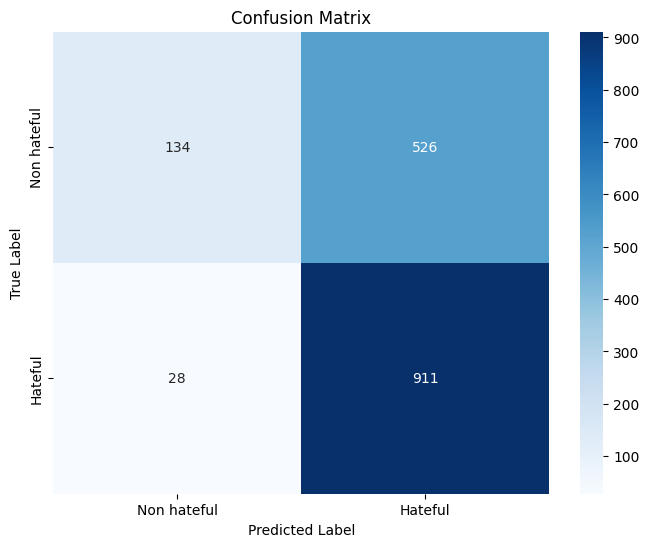

In [ ]:
print_confusion_matrix(test_df['label'], preds_df['label'])

## ¿Cómo fine-tuneamos un modelo?

En esta sección, veremos un procedimiento "típico" de *fine-tuning* para adaptar un modelo pre-entrenado a nuestra tarea de clasificación de sentimientos. Sin embargo, debido a que el proceso de entrenamiento puede tomar un tiempo considerable, no ejecutaremos las celdas en este cuaderno. En su lugar, utilizaremos un modelo que ya ha sido *fine-tuneado* (mostrado más adelante en las celdas del código) para demostrar los resultados y cómo se podría aplicar en la práctica.

In [ ]:
# Convertimos los dataframes a Hugging Face Dataset
train_dataset = Dataset.from_pandas(train_df[['text', 'label']])
test_dataset = Dataset.from_pandas(test_df[['text', 'label']])
val_dataset = Dataset.from_pandas(dev_df[['text', 'label']])

Primero, convertimos los dataframes a Datasets. Aunque los DataFrames de pandas son versátiles, los objetos `Dataset` de Hugging Face están optimizados para el procesamiento del lenguaje natural y la integración con la biblioteca `transformers`.

Sus principales ventajas son:

1.  **Eficiencia**: Manejan grandes volúmenes de datos de forma más eficiente en memoria y velocidad, usando formatos como Apache Arrow y permitiendo la carga perezosa (lazy loading).
2.  **Integración Directa**: Se integran de forma nativa con funciones de `transformers` como el tokenizador y el `Trainer`, simplificando el flujo de trabajo.
3.  **Funcionalidades Específicas para PLN**: Ofrecen características útiles para PLN, como el mapeo optimizado de funciones para preprocesamiento por lotes.

In [ ]:
# Cargamos el tokenizador
model_name = "pysentimiento/robertuito-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

from pysentimiento.preprocessing import preprocess_tweet

def tokenize_function(examples):
    textos = [preprocess_tweet(t, lang="es") for t in examples["text"]]   # ← lo único nuevo
    return tokenizer(textos, truncation=True, padding="max_length", max_length=128)

# Apply tokenization to the datasets
tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)
tokenized_val_dataset = val_dataset.map(tokenize_function, batched=True)

config.json:   0%|          | 0.00/677 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/323 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/858k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Map:   0%|          | 0/4500 [00:00<?, ? examples/s]

Map:   0%|          | 0/1599 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Acá pasaron varias cosas:

1.  **Carga del Tokenizador de Spanish BERT (`model_name`, `tokenizer = AutoTokenizer.from_pretrained(model_name)`)**:
    *   `model_name = "dccuchile/bert-base-spanish-wwm-cased"`: Se especifica el nombre del modelo pre-entrenado de BERT en español que se utilizará. Este modelo es de la Universidad de Chile y está entrenado para español. `wwm` (Whole Word Masking) y `cased` (sensible a mayúsculas/minúsculas) son características de este modelo.
    *   `tokenizer = AutoTokenizer.from_pretrained(model_name)`: `AutoTokenizer` es una clase de Hugging Face que automáticamente carga el tokenizador adecuado para el `model_name` especificado. Este tokenizador es responsable de convertir el texto crudo en los identificadores numéricos (input IDs), máscaras de atención (attention masks) y tipos de segmento (token type IDs) que el modelo BERT puede entender. Al usar `from_pretrained`, se descargan el vocabulario y la configuración específica de tokenización de ese modelo.

2.  **Función para Tokenizar los Datos (`def tokenize_function(examples):`)**:
    *   Esta función toma un diccionario de ejemplos (`examples`) que contiene el texto. Se utiliza dentro del método `map` de Hugging Face `Dataset` para procesar el conjunto de datos por lotes.
    *   `tokenizer(examples["text"], ...)`: Aplica el tokenizador cargado a la columna `"text"` de los ejemplos.
    *   `truncation=True`: Si una secuencia de texto es más larga que el `max_length` especificado, se truncará para ajustarse a ese límite.
    *   `padding="max_length"`: Las secuencias que son más cortas que `max_length` se rellenarán (padding) con tokens especiales (`[PAD]`) hasta alcanzar esa longitud. Esto es necesario porque los modelos BERT esperan entradas de longitud uniforme.
    *   `max_length=128`: Define la longitud máxima de las secuencias tokenizadas. BERT-base suele tener un límite de 512, pero 128 es común para tareas de clasificación para ahorrar recursos computacionales.

3.  **Función para Computar Métricas (`def compute_metrics(pred):`)**:
    *   Esta función es crucial para evaluar el rendimiento del modelo durante y después del entrenamiento. El `Trainer` de Hugging Face la utiliza para calcular métricas en el conjunto de validación.
    *   `labels = pred.label_ids`: Contiene las etiquetas verdaderas del conjunto de datos.
    *   `preds = pred.predictions.argmax(-1)`: Los `pred.predictions` son los *logits* (puntuaciones de salida sin normalizar) del modelo. `argmax(-1)` toma el índice de la puntuación más alta a lo largo del último eje (que corresponde a las clases), convirtiendo los logits en las predicciones de clase.
    *   `precision, recall, f1, _ = precision_recall_fscore_support(...)`: Calcula la precisión, exhaustividad (recall) y la puntuación F1. `average='binary'` es adecuado para clasificación binaria, y `pos_label='Positive'` o el valor numérico de la clase positiva (en este caso, 1) especifica qué clase se considera la positiva para el cálculo de estas métricas.
    *   `acc = accuracy_score(labels, preds)`: Calcula la precisión global del modelo.
    *   La función devuelve un diccionario con todas estas métricas, lo que permite al `Trainer` registrarlas y utilizarlas para la selección del mejor modelo.

4.  **Aplicación de la Tokenización a los Datasets (`tokenized_train_dataset = train_dataset.map(...)`)**:
    *   `dataset.map(tokenize_function, batched=True)`: Este es un método eficiente de Hugging Face `Dataset` para aplicar una función de preprocesamiento a todo el conjunto de datos.
    *   `batched=True`: Indica que la `tokenize_function` se aplicará a múltiples ejemplos a la vez (en lotes), lo cual es más eficiente que procesar cada ejemplo individualmente, especialmente con tokenizadores que pueden manejar entradas por lotes.
    *   El resultado son nuevos objetos `Dataset` (`tokenized_train_dataset`, `tokenized_test_dataset`, `tokenized_val_dataset`) donde el texto original ha sido reemplazado por los `input_ids`, `attention_mask` y `token_type_ids` generados por el tokenizador.

In [ ]:
# Cargamos el modelo pre-entrenado base
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    id2label={0: "Not hateful", 1: "Hateful"},
    label2id={"Not hateful": 0, "Hateful": 1},
)

In [ ]:
os.environ["TENSORBOARD_LOGGING_DIR"] = "./logs"

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,                  # era 2e-6
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,       # eval no guarda gradientes, puede ser más grande
    num_train_epochs=5,
    weight_decay=0.01,
    warmup_steps=0.1,     # float <1 = proporción (requiere transformers v5; en v4 usar warmup_ratio)
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",    # tiene que coincidir con compute_metrics
    save_total_limit=1,                  # 5 checkpoints = ~2 GB en /content
    fp16=torch.cuda.is_available(),                           # ~2x más rápido en T4
    report_to="none",                    # evita que pregunte por W&B
)

Definimos los siguientes argumentos:

- **`output_dir`** — Directorio donde se guardan los checkpoints del modelo, los logs y el modelo final. Es el único parámetro obligatorio. Se recomienda usar un path descriptivo que incluya el nombre del modelo y la tarea, por ejemplo `"./results/bert-sentimiento"`.

- **`eval_strategy`** — Define cuándo se evalúa el modelo sobre el conjunto de validación. Los valores posibles son `"no"`, `"epoch"` (al final de cada época) y `"steps"` (cada `eval_steps` pasos). Para datasets grandes donde una época implica miles de pasos, conviene usar `"steps"` para tener feedback más frecuente.

- **`save_strategy`** — Análogo a `eval_strategy`, controla cuándo se guarda un checkpoint a disco. Para que `load_best_model_at_end=True` funcione correctamente, `save_strategy` y `eval_strategy` deben estar alineados — ambos `"epoch"` o ambos `"steps"`.

- **`learning_rate`** — Tasa de aprendizaje inicial para el optimizador AdamW. Para fine-tuning de transformers, el rango recomendado por el paper original de BERT es `2e-5` a `5e-5`. Valores más altos pueden desestabilizar los pesos preentrenados del encoder; valores más bajos ralentizan la convergencia de la cabeza de clasificación.

- **`per_device_train_batch_size`** — Tamaño del batch de entrenamiento por dispositivo. El batch efectivo total es `per_device_train_batch_size × número de GPUs`. Con BERT-base, un valor de 16 es viable en GPUs con 8-16GB de VRAM. Si se produce un error de memoria, reducir a 8 y compensar con `gradient_accumulation_steps=2`.

- **`per_device_eval_batch_size`** — Tamaño del batch durante la evaluación. Como no requiere almacenar gradientes, puede usarse un valor más alto que el de entrenamiento sin riesgo de quedarse sin memoria.

- **`num_train_epochs`** — Número de pasadas completas sobre el dataset de entrenamiento. Para fine-tuning de BERT el rango típico es de 3 a 5 épocas. Con datasets pequeños, más épocas aumentan el riesgo de overfitting; con datasets grandes, 2 o 3 suelen ser suficientes.

- **`weight_decay`** — Factor de regularización L2 aplicado a los pesos del modelo. Penaliza pesos de magnitud grande, reduciendo el riesgo de overfitting. Se aplica a todos los parámetros excepto biases y capas de normalización. El valor `0.01` es el punto de partida recomendado.

- **`logging_steps`** — Frecuencia con la que se registran métricas de entrenamiento (loss, learning rate, etc.). Indica cada cuántos pasos de optimización se genera un registro. Con datasets muy grandes conviene aumentarlo para no saturar el sistema de logging.

- **`load_best_model_at_end`** — Si es `True`, al finalizar el entrenamiento el `Trainer` carga automáticamente el checkpoint con mejor performance en validación, en lugar del último. Requiere que `save_strategy` y `eval_strategy` estén alineados.

- **`metric_for_best_model`** — Métrica utilizada para determinar el mejor checkpoint cuando `load_best_model_at_end=True`. Por defecto usa `"loss"` de validación. Para clasificación con clases desbalanceadas se recomienda `"f1"` o `"accuracy"`, definidas a través del argumento `compute_metrics` del `Trainer`.

- **`warmup_ratio`** — Proporción del total de pasos durante los cuales el learning rate aumenta linealmente desde 0 hasta el valor definido, antes de comenzar el decaimiento. Es especialmente importante en fine-tuning porque la cabeza de clasificación comienza con pesos aleatorios: sin warmup, las primeras actualizaciones pueden dañar los pesos preentrenados del encoder.

In [ ]:
# Define the label mapping
label_to_int = {'Not hateful': 0, 'Hateful': 1}

# Convert string labels to numerical labels in the datasets
tokenized_train_dataset = tokenized_train_dataset.map(lambda x: {'label': label_to_int[x['label']]}, batched=False)
tokenized_test_dataset = tokenized_test_dataset.map(lambda x: {'label': label_to_int[x['label']]}, batched=False)
tokenized_val_dataset = tokenized_val_dataset.map(lambda x: {'label': label_to_int[x['label']]}, batched=False)


En **`label_to_int = {'Negative': 0, 'Positive': 1}`**: Se define un diccionario `label_to_int` que establece el mapeo directo entre las etiquetas de texto y sus correspondientes valores enteros. En este caso, 'Negative' se mapea a `0` y 'Positive' a `1`.

En el segundo bloque, **`tokenized_train_dataset = tokenized_train_dataset.map(lambda x: {'label': label_to_int[x['label']]}, batched=False)`** (y las líneas análogas para `tokenized_test_dataset` y `tokenized_val_dataset`):

*   Se utiliza el método `map` de los objetos `Dataset` de Hugging Face para aplicar una función a cada elemento del dataset.
*   La función `lambda x: {'label': label_to_int[x['label']]}` toma cada `ejemplo (x)` del dataset, accede a su etiqueta original (en formato de texto, `x['label']`), busca su valor numérico correspondiente en el diccionario `label_to_int`, y reemplaza la columna `'label'` del ejemplo con este nuevo valor entero.
*   `batched=False` indica que la función `lambda` se aplicará individualmente a cada ejemplo en lugar de a lotes de ejemplos. Aunque `batched=True` suele ser más eficiente para tokenización, para un simple mapeo de etiquetas como este, `batched=False` es suficiente y claro.

In [ ]:
%%time

# Definimos una función para computar métricas
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')

    return {
        'accuracy':  accuracy_score(labels, preds),
        'macro_f1':  f1_score(labels, preds, average='macro'),  # la métrica oficial
        'f1_hate':   f1,   # F1 de la clase positiva únicamente
        'precision': p,
        'recall':    r,
    }


# Creamos el entrenador
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_val_dataset,
    compute_metrics=compute_metrics,
    processing_class=tokenizer
)

print("Starting BERT model training...")
# Entrenamos el modelo
trainer.train()

Starting BERT model training...
{'loss': '0.7216', 'grad_norm': '5.747', 'learning_rate': '1.277e-06', 'epoch': '0.03546'}
{'loss': '0.7071', 'grad_norm': '4.979', 'learning_rate': '2.695e-06', 'epoch': '0.07092'}
{'loss': '0.7078', 'grad_norm': '4.432', 'learning_rate': '4.113e-06', 'epoch': '0.1064'}
{'loss': '0.6791', 'grad_norm': '4.053', 'learning_rate': '5.532e-06', 'epoch': '0.1418'}
{'loss': '0.67', 'grad_norm': '4.125', 'learning_rate': '6.95e-06', 'epoch': '0.1773'}
{'loss': '0.6184', 'grad_norm': '4.045', 'learning_rate': '8.369e-06', 'epoch': '0.2128'}
{'loss': '0.6493', 'grad_norm': '4.163', 'learning_rate': '9.787e-06', 'epoch': '0.2482'}
{'loss': '0.6256', 'grad_norm': '3.831', 'learning_rate': '1.121e-05', 'epoch': '0.2837'}
{'loss': '0.5986', 'grad_norm': '4.531', 'learning_rate': '1.262e-05', 'epoch': '0.3191'}
{'loss': '0.6107', 'grad_norm': '3.736', 'learning_rate': '1.404e-05', 'epoch': '0.3546'}
{'loss': '0.5423', 'grad_norm': '4.333', 'learning_rate': '1.546e-05'

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.2756', 'grad_norm': '4.093', 'learning_rate': '1.767e-05', 'epoch': '1.028'}
{'loss': '0.2569', 'grad_norm': '4.331', 'learning_rate': '1.751e-05', 'epoch': '1.064'}
{'loss': '0.2364', 'grad_norm': '7.291', 'learning_rate': '1.735e-05', 'epoch': '1.099'}
{'loss': '0.3091', 'grad_norm': '19.36', 'learning_rate': '1.719e-05', 'epoch': '1.135'}
{'loss': '0.1724', 'grad_norm': '10.22', 'learning_rate': '1.704e-05', 'epoch': '1.17'}
{'loss': '0.1796', 'grad_norm': '7.932', 'learning_rate': '1.688e-05', 'epoch': '1.206'}
{'loss': '0.2724', 'grad_norm': '10.65', 'learning_rate': '1.672e-05', 'epoch': '1.241'}
{'loss': '0.1801', 'grad_norm': '8.262', 'learning_rate': '1.656e-05', 'epoch': '1.277'}
{'loss': '0.1868', 'grad_norm': '5.143', 'learning_rate': '1.641e-05', 'epoch': '1.312'}
{'loss': '0.289', 'grad_norm': '5.48', 'learning_rate': '1.625e-05', 'epoch': '1.348'}
{'loss': '0.1747', 'grad_norm': '7.28', 'learning_rate': '1.609e-05', 'epoch': '1.383'}
{'loss': '0.2401', 'grad_

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.1045', 'grad_norm': '3.056', 'learning_rate': '1.325e-05', 'epoch': '2.021'}
{'loss': '0.1004', 'grad_norm': '2.529', 'learning_rate': '1.31e-05', 'epoch': '2.057'}
{'loss': '0.1063', 'grad_norm': '6.374', 'learning_rate': '1.294e-05', 'epoch': '2.092'}
{'loss': '0.1802', 'grad_norm': '6.734', 'learning_rate': '1.278e-05', 'epoch': '2.128'}
{'loss': '0.08349', 'grad_norm': '6.765', 'learning_rate': '1.262e-05', 'epoch': '2.163'}
{'loss': '0.07741', 'grad_norm': '12.73', 'learning_rate': '1.247e-05', 'epoch': '2.199'}
{'loss': '0.1238', 'grad_norm': '9.799', 'learning_rate': '1.231e-05', 'epoch': '2.234'}
{'loss': '0.09268', 'grad_norm': '10.31', 'learning_rate': '1.215e-05', 'epoch': '2.27'}
{'loss': '0.1755', 'grad_norm': '0.1447', 'learning_rate': '1.199e-05', 'epoch': '2.305'}
{'loss': '0.1681', 'grad_norm': '15.11', 'learning_rate': '1.184e-05', 'epoch': '2.34'}
{'loss': '0.09413', 'grad_norm': '3.836', 'learning_rate': '1.168e-05', 'epoch': '2.376'}
{'loss': '0.1284', 

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.07516', 'grad_norm': '6.58', 'learning_rate': '4.429e-06', 'epoch': '4.007'}
{'loss': '0.02892', 'grad_norm': '11.88', 'learning_rate': '4.271e-06', 'epoch': '4.043'}
{'loss': '0.01374', 'grad_norm': '0.1496', 'learning_rate': '4.113e-06', 'epoch': '4.078'}
{'loss': '0.04159', 'grad_norm': '1.321', 'learning_rate': '3.956e-06', 'epoch': '4.113'}
{'loss': '0.0255', 'grad_norm': '0.1437', 'learning_rate': '3.798e-06', 'epoch': '4.149'}
{'loss': '0.0893', 'grad_norm': '2.519', 'learning_rate': '3.641e-06', 'epoch': '4.184'}
{'loss': '0.06173', 'grad_norm': '0.07291', 'learning_rate': '3.483e-06', 'epoch': '4.22'}
{'loss': '0.01678', 'grad_norm': '0.07032', 'learning_rate': '3.325e-06', 'epoch': '4.255'}
{'loss': '0.03472', 'grad_norm': '0.02414', 'learning_rate': '3.168e-06', 'epoch': '4.291'}
{'loss': '0.0456', 'grad_norm': '25.28', 'learning_rate': '3.01e-06', 'epoch': '4.326'}
{'loss': '0.01403', 'grad_norm': '0.1654', 'learning_rate': '2.853e-06', 'epoch': '4.362'}
{'loss'

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '237.9', 'train_samples_per_second': '94.57', 'train_steps_per_second': '5.926', 'train_loss': '0.1892', 'epoch': '5'}
CPU times: user 2min 41s, sys: 6.52 s, total: 2min 47s
Wall time: 3min 58s


TrainOutput(global_step=1410, training_loss=0.18915451206531084, metrics={'train_runtime': 237.9266, 'train_samples_per_second': 94.567, 'train_steps_per_second': 5.926, 'train_loss': 0.18915451206531084, 'epoch': 5.0})

In [ ]:
print(trainer.evaluate(tokenized_test_dataset))

{'eval_loss': '0.9018', 'eval_accuracy': '0.8118', 'eval_macro_f1': '0.8089', 'eval_f1_hate': '0.7855', 'eval_precision': '0.7416', 'eval_recall': '0.8348', 'eval_runtime': '2.946', 'eval_samples_per_second': '542.7', 'eval_steps_per_second': '8.486', 'epoch': '5'}
{'eval_loss': 0.9017751812934875, 'eval_accuracy': 0.8117573483427142, 'eval_macro_f1': 0.8088858534338474, 'eval_f1_hate': 0.7854597291518175, 'eval_precision': 0.7415881561238223, 'eval_recall': 0.8348484848484848, 'eval_runtime': 2.9462, 'eval_samples_per_second': 542.736, 'eval_steps_per_second': 8.486, 'epoch': 5.0}


Cuando llamamos al método `trainer.train()`, se inicia el ciclo de entrenamiento del modelo. Este proceso es orquestado por la clase `Trainer` de Hugging Face y generalmente incluye los siguientes pasos clave:

1.  **Configuración Inicial**: Antes de que comience el bucle de entrenamiento, el `Trainer` realiza algunas configuraciones:

  *   **Optimizador y Programador de Tasa de Aprendizaje**: Inicializa el optimizador (por ejemplo, AdamW) y, si se especifican, un programador de tasa de aprendizaje (learning rate scheduler) basado en los `TrainingArguments` proporcionados.
  *   **Dispositivo**: Mueve el modelo al dispositivo de computación adecuado (GPU si está disponible, o CPU).
  *   **Comprobación de Checkpoints**: Si se especifica, el `Trainer` comprueba si hay checkpoints guardados y, en caso afirmativo, carga el estado del modelo, optimizador y programador para reanudar el entrenamiento.

2.  **Bucle de Épocas (Epoch Loop)**: El entrenamiento se ejecuta durante un número predefinido de épocas (`num_train_epochs` en `TrainingArguments`). Por cada época:

    a.  **Modo de Entrenamiento**: El modelo se pone en modo de entrenamiento (`model.train()`) para asegurar que las capas  como Dropout y BatchNorm se comporten correctamente para el entrenamiento.   
    b.  **Bucle de Datos de Entrenamiento (Training Data Loop)**:
      
    *   El `train_dataset` se convierte en un `DataLoader` para cargar datos en batches. Si `shuffle=True` en los argumentos, los datos se barajan en cada época.
      
    *   Para cada batch de datos:
            *   **Preprocesamiento por el Modelo**: El batch de datos tokenizados (ids de entrada, máscara de atención, etc.) se pasa al modelo. El modelo realiza una pasada hacia adelante (forward pass) y calcula las *logits* (puntuaciones de salida sin normalizar).
            *   **Cálculo de la Pérdida (Loss)**: La función de pérdida (generalmente una Cross-Entropy Loss para clasificación) compara las logits del modelo con las etiquetas verdaderas (`label`) y calcula un valor escalar que representa cuán lejos están las predicciones del modelo de la realidad.
            *   **Retropropagación (Backward Pass)**: Se calcula el gradiente de la pérdida con respecto a los pesos del modelo. Esto se hace usando la retropropagación (`loss.backward()`).
            *   **Actualización de Pesos**: El optimizador utiliza estos gradientes para actualizar los pesos del modelo, minimizando la pérdida (`optimizer.step()`).
            *   **Limpieza de Gradientes**: Los gradientes se ponen a cero para el siguiente batch (`optimizer.zero_grad()`).
            *   **Actualización del Programador**: Si se usa un programador de tasa de aprendizaje, se actualiza la tasa de aprendizaje (`scheduler.step()`).

    c.  **Evaluación (Evaluation Loop - Opcional)**:
        Si se especifica una estrategia de evaluación (`eval_strategy`) y un `eval_dataset`, el `Trainer` pausará el entrenamiento y realizará una evaluación:
          
      *   **Modo de Evaluación**: El modelo se pone en modo de evaluación (`model.eval()`) para desactivar comportamientos de entrenamiento como Dropout.
      *   **Bucle de Datos de Evaluación**: Se itera sobre el `eval_dataset` en batches. Para cada batch, se realiza una pasada hacia adelante, pero **no** se calculan gradientes ni se actualizan pesos (`torch.no_grad()`).
      *   **Cálculo de Métricas**: Se recogen las predicciones del modelo y las etiquetas verdaderas. Al final del bucle de evaluación, la función `compute_metrics` (que definimos anteriormente) se llama para calcular métricas como la precisión, recall, F1-score y exactitud.

    d.  **Registro (Logging)**:
        Durante el entrenamiento y después de cada evaluación, el `Trainer` registra las pérdidas y las métricas en un directorio de logs (por ejemplo, para TensorBoard). Esto permite monitorear el progreso del entrenamiento.

    e.  **Guardado de Checkpoints (Saving Checkpoints)**:
        Si se configura, el `Trainer` guarda el estado actual del modelo y del optimizador en un checkpoint después de cada época (o según la estrategia definida), lo que permite reanudar el entrenamiento más tarde o guardar el mejor modelo.

3.  **Finalización**: Una vez que se completan todas las épocas, el método `trainer.train()` devuelve un objeto `TrainOutput` que contiene información sobre el entrenamiento, como la duración total y la mejor métrica.


Hasta allí el código para finetunear, para que no tarde tanto, vamos a cargar el modelo ya pre-entrenado sobre ese mismo dataset y con el mismo código. Una opción es cargarlo como `pipeline` como vimos antes.

In [ ]:
model_ft = "gefero/replicate-HatEval-robertuito-base-uncased"
texts = test_df["text"].tolist()

In [ ]:
pipe = pipeline("text-classification", model=model_ft)

model.safetensors: reconstructing file:   0%|          |  0.00B /  435MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/531 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.16M [00:00<?, ?B/s]

In [ ]:
%time preds_fine_tuned = pipe(texts, truncation=True, max_length=128)

CPU times: user 21.1 s, sys: 29 ms, total: 21.2 s
Wall time: 27.9 s


In [ ]:
preds_ft_df = pd.DataFrame(preds_fine_tuned)

In [ ]:
compare_performance(test_df['label'], preds_ft_df['label'])

{'Accuracy': 0.8005003126954346,
 'Precision': 0.7300944669365722,
 'Recall': 0.8196969696969697,
 'F1': 0.7723054960742327}

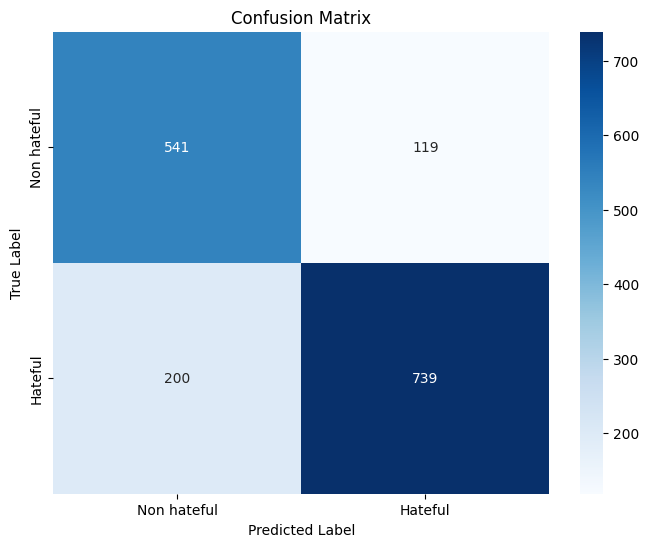

In [ ]:
print_confusion_matrix(test_df['label'], preds_ft_df['label'])

Pero vamos a hacerlo paso a paso. Tengamos como referencia este esquema:



In [ ]:
# 1.Cargamos el tokenizer y el modelo
model_path = model_ft
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)
model.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(30000, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(130, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

Acá cargamos el tokenizador y el modelo. Un punto importante es que `model.eval()` modifica el comportamiento de tipos específicos de capas. Ahora todas las neuronas están activas y la salida es determinista. Las capas de `BatchNorm` dejan de usar estadísticas del lote actual y pasan a usar las estadísticas acumuladas durante el entrenamiento. Esta llamada se hace una sola vez antes del loop de inferencia.

In [ ]:
id2label = model.config.id2label

BATCH_SIZE = 12 # definimos el tamaño de los batches

results = [] # lista vacía para
batches = range(0, len(texts), BATCH_SIZE)

for i in tqdm(batches, desc="Clasificando textos", unit="lote"):
    batch_texts = texts[i : i + BATCH_SIZE]

    encoded = tokenizer(
        batch_texts,
        padding=True,
        truncation=True,
        max_length=128, # Changed from 512 to 128 to match model's max_position_embeddings
        return_tensors="pt"
    )

    with torch.no_grad():
        outputs = model(**encoded)

    probs = torch.softmax(outputs.logits, dim=-1)
    predicted_ids = torch.argmax(probs, dim=-1)

    for idx, prob in zip(predicted_ids, probs):
        results.append({
            "predicted_label": id2label[idx.item()],
            "confidence": prob.max().item()
        })

    del encoded, outputs
    gc.collect()

Clasificando textos: 100%|██████████| 134/134 [03:43<00:00,  1.67s/lote]


Veamos este código con cierto detalle.

El loop itera por cada batch de `texts`(de tamaño 12). En cada iteración (o sea, sobre cada batch)

- tokeniza el batch (`encoded = tokenize(..,)`, son importantes los siguientes argumentos:
  - `padding=True`: rellena todas las secuencias del lote hasta la longitud de la más larga, usando un token especial [PAD]. Esto es necesario porque los tensores de PyTorch requieren dimensiones uniformes dentro del lote.
  - `truncation=True`: cualquier secuencia más larga que max_length es recortada. Los modelos basados en BERT tienen un límite arquitectónico estricto de 512 tokens, impuesto por los embeddings posicionales.
  - `max_length=512`: este valor debería coincidir con el utilizado durante el fine-tuning. Si el modelo fue entrenado con un límite menor (por ejemplo, 128), truncar en 512 es inofensivo, pero conviene replicar exactamente la configuración de entrenamiento.
  -`return_tensors="pt"`: devuelve tensores de PyTorch directamente. La salida es un diccionario con `claves input_ids`, `attention_mask`  y, posiblemente, `token_type_ids` (en BERT clásico; no se usa en variantes como RoBERTa).

- realiza la inferencia sobre el batch. Aquí, `torch.no_grad()` es un gestor de contexto que desactiva la construcción del grafo computacional. Durante el entrenamiento, PyTorch registra cada operación sobre tensores para poder calcular gradientes mediante backpropagation. En inferencia, ese seguimiento es innecesario y consume memoria y cómputo de forma inútil. `torch.no_grad()` elimina ese overhead. Debe envolver cada forward pass. La salida `outputs.logits` tiene shape `(BATCH_SIZE, num_labels)`: una fila por texto, una columna por clase.

- el modelo devuelve logits crudos: un puntaje de valor real por clase, sin restricción sobre su rango ni su suma. Son las salidas de la última capa lineal, antes de cualquier normalización.
  - `torch.softmax` los convierte en una distribución de probabilidad válida: todos los valores se vuelven positivos y suman 1. Esto permite obtener un puntaje de confianza junto con la clase predicha.
  - `torch.argmax` selecciona el índice con mayor probabilidad. Nótese que aplicar `argmax` directamente sobre los logits produce la misma clase que aplicarlo sobre las probabilidades `softmax`, ya que `softmax` es una transformación monótona. El `softmax` solo es necesario aquí porque también queremos la columna `confidence`; si solo se necesita la clase predicha, puede omitirse y aplicar `argmax` directamente sobre `outputs.logits`.

- `for idx, prob in zip(predicted_ids, probs)...` itera en paralelo sobre los índices predichos y las probabilidades, una entrada por texto del lote. zip empareja el idx y el vector prob correspondiente a cada texto.
- `del encoded, `outputs` / `gc.collect()`, libera explícitamente los tensores del lote actual antes de pasar al siguiente. Sin esto, los tensores se acumulan en memoria.

In [ ]:
pred_test_ft = pd.DataFrame(results)

In [ ]:
compare_performance(test_df['label'].values, pred_test_ft['predicted_label'])

{'Accuracy': 0.8005003126954346,
 'Precision': 0.7300944669365722,
 'Recall': 0.8196969696969697,
 'F1': 0.7723054960742327}

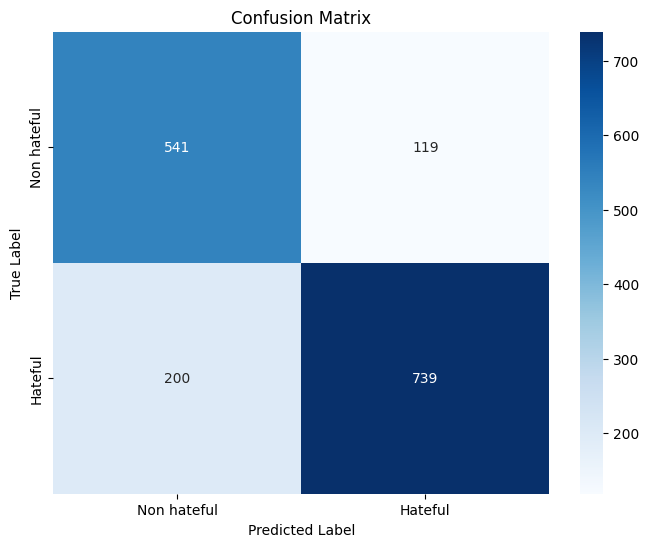

In [ ]:
print_confusion_matrix(test_df['label'].values, pred_test_ft['predicted_label'])

## Persisitendo el modelo
Desde un entorno local, ejecutando esta línea de código podemos persistir el modelo en el disco.

In [ ]:
#trainer.save_model("./final_model")

Para hacerlo desde Colab tenemos, además, que comprimir la carpeta y luego descargarla a nuestro entorno local.

In [ ]:
#!zip -r final_model.zip ./final_model
#from google.colab import files
#files.download("final_model.zip")

Por último, podríamos subir el modelo al repositorio de [HuggingFace](https://huggingface.co/). Para eso, hay que abrir una cuenta, generar un token y ejecutar las siguientes líneas:

In [ ]:
# Nos logueamos a HugginFace
#from huggingface_hub import login
#from google.colab import userdata
#login(userdata.get('HF_Colab2'))

# Y pusheamos el modelo y el tokenizador
#model.push_to_hub("gefero/replicate-HatEval-robertuito-base-uncased")
#tokenizer.push_to_hub("gefero/replicate-HatEval-robertuito-base-uncased")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...oqbgt9x/model.safetensors:   0%|          | 14.4kB /  435MB            

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/gefero/replicate-HatEval-robertuito-base-uncased/commit/f98c6b3a6799ad4c3945e45b2f06a8634e622b2f', commit_message='Upload tokenizer', commit_description='', oid='f98c6b3a6799ad4c3945e45b2f06a8634e622b2f', pr_url=None, repo_url=RepoUrl('https://huggingface.co/gefero/replicate-HatEval-robertuito-base-uncased', endpoint='https://huggingface.co', repo_type='model', repo_id='gefero/replicate-HatEval-robertuito-base-uncased'), pr_revision=None, pr_num=None)

## Ejercicio

### Parte 1 — Búsqueda del modelo en HuggingFace

- Ingresar a huggingface.co/models y buscar un modelo de análisis de sentimiento distinto al usado en clase. Podés filtrar por:
- Task: Text Classification
- Language: Spanish (u otro idioma, si lo justificás)

Para el modelo elegido, responder:

- ¿Cuál es el nombre del modelo (checkpoint)?
- ¿Sobre qué corpus fue pre-entrenado? ¿Y fine-tuneado?
- ¿Qué etiquetas de salida tiene (id2label)? ¿Son directamente comparables con las del dataset de Amazon (Positive/Negative)? ¿Qué transformación necesitás aplicar?

In [ ]:
chkp = "piuba-bigdata/beto-contextualized-hate-speech"
pipe_ex = pipeline(
    "text-classification",
    model=chkp,
    top_k=None
)

config.json:   0%|          | 0.00/1.14k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  439MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/588 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/242k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/730k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/78.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

### Parte 2 — Aplicación al dataset de Twitter
Usando el mismo test_df construido en clase, aplicar el modelo elegido mediante `pipeline()` y generar las predicciones. Tener en cuenta que puede ser necesario adaptar las etiquetas del modelo a las del dataset antes de calcular métricas.


In [ ]:
df_tweets = pd.read_csv('./factor_data_tuto_NLP_SICSS/data/tweets_menciones.zip', compression='zip')

In [ ]:
df_tweets_sample = df_tweets.sample(n=1000, random_state=123)
df_tweets_sample.head()

,id_str,in_reply_to_status_id,in_reply_to_user_id,created,retweeted,language,source,lon,lat,place_name,...,friends_count,user_description,user_created,user_statuses_count,user_verified,tweet,text,n_favorites,n_retweets,tweet_proc
105359,1.622282e+18,1.622010e+18,1.463329e+18,2023-02-05,False,es,Twitter for Android,NaN,NaN,NaN,...,462,NaN,2019-05-18T19:36:40Z,905,False,@Lu_bertotto @florenciarietto @PatoBullrich No...,@Lu_bertotto @florenciarietto @PatoBullrich No...,0,0,@usuario @usuario @usuario No tienen nada que ...
131545,1.622679e+18,1.622600e+18,1.937826e+08,2023-02-06,False,es,Twitter for iPhone,NaN,NaN,NaN,...,158,"comercial en swonkie, hincha de Racing club de...",2014-10-20T16:12:35Z,225,False,@marcelopueIIaok @alferdez @alferdez dijiste q...,@marcelopueIIaok @alferdez @alferdez dijiste q...,0,0,@usuario @usuario @usuario dijiste que podíamo...
10719,1.621203e+18,1.620932e+18,1.528355e+08,2023-02-02,False,es,Twitter Web App,NaN,NaN,NaN,...,5,NaN,2023-01-04T17:39:57Z,33,False,"@JuanGrabois Zurdo de cuarta,hablas de invasor...","@JuanGrabois Zurdo de cuarta,hablas de invasor...",0,0,"@usuario Zurdo de cuarta,hablas de invasor car..."
35683,1.621349e+18,1.621342e+18,7.389672e+17,2023-02-03,False,es,Twitter for Android,NaN,NaN,NaN,...,227,"Biólogo de Iquitos, hincha del mas grande del ...",2012-08-08T19:54:58Z,4796,False,@cathacastaneda @ManuelaC22 Responde poniendo ...,@cathacastaneda @ManuelaC22 Responde poniendo ...,0,0,@usuario @usuario Responde poniendo los video ...
225968,1.623426e+18,1.623112e+18,7.700945e+07,2023-02-08,False,es,Twitter for Android,NaN,NaN,NaN,...,923,NaN,2012-11-08T22:44:31Z,35804,False,@horaciorlarreta Como era? No importan las pal...,@horaciorlarreta Como era? No importan las pal...,0,0,@usuario Como era? No importan las palabras si...


In [ ]:
texts = df_tweets_sample["tweet"].tolist()
%time preds_nuevo = pipe_ex(texts, truncation=True, max_length=512)

CPU times: user 14.1 s, sys: 40 ms, total: 14.2 s
Wall time: 17.7 s


In [ ]:
preds_nuevo

[[{'label': 'POLITICS', 'score': 0.0009547311346977949},
  {'label': 'WOMEN', 'score': 0.0007833768031559885},
  {'label': 'RACISM', 'score': 0.0007436001324094832},
  {'label': 'APPEARANCE', 'score': 0.0006207092083059251},
  {'label': 'DISABLED', 'score': 0.000512903556227684},
  {'label': 'CRIMINAL', 'score': 0.0005071493214927614},
  {'label': 'CLASS', 'score': 0.0004569229204207659},
  {'label': 'LGBTI', 'score': 0.0004433754656929523},
  {'label': 'CALLS', 'score': 0.00044057791819795966}],
 [{'label': 'RACISM', 'score': 0.0008722674683667719},
  {'label': 'WOMEN', 'score': 0.0007889298722147942},
  {'label': 'APPEARANCE', 'score': 0.0006871871300972998},
  {'label': 'POLITICS', 'score': 0.0006427525659091771},
  {'label': 'DISABLED', 'score': 0.0005458177183754742},
  {'label': 'CLASS', 'score': 0.00047265595640055835},
  {'label': 'LGBTI', 'score': 0.00045285598025657237},
  {'label': 'CRIMINAL', 'score': 0.0004483902011997998},
  {'label': 'CALLS', 'score': 0.00039977367850951

In [ ]:
1def adapt_label(scores_list):
    sorted_scores = sorted(scores_list, key=lambda x: x['score'], reverse=True)
    for item in sorted_scores:
        if item['label'].lower() != 'neutral':
            return item['label'].capitalize()
    return sorted_scores[0]['label'].capitalize()

labels_nuevo = [adapt_label(pred) for pred in preds_nuevo]
pd.Series(labels_nuevo).value_counts()

,count
Label_0,662
Label_1,238


### Parte 3 — Comparación de performance
Calcular accuracy, precision, recall y F1 sobre el conjunto de test, usando `compare_performance()` y `print_confusion_matrix`(). Armar una tabla que compare los tres modelos.

In [ ]:
compare_performance(test_df['label'], labels_nuevo)

{'Accuracy': 0.8716666666666667,
 'Precision': 0.9346978557504874,
 'Recall': 0.7991666666666667,
 'F1': 0.8616352201257862}

## Parte 4 — Estructura interna del modelo
Cargar el modelo con `AutoTokenizer.from_pretrained()` y `AutoModelForSequenceClassification.from_pretrained()` (sin usar pipeline). Luego:

- Imprimir model.config e identificar: número de capas, número de attention heads, tamaño del hidden state y vocabulario.

- Tokenizar el siguiente texto y mostrá los `input_ids` y el `attention_mask` resultantes:

> "El producto llegó tarde y en mal estado, pero el vendedor respondió rápido."


- Realizar un forward pass con `torch.no_grad()` e imprimir la forma (shape) del tensor outputs.logits. ¿Qué representa cada dimensión?
- Aplicá `torch.softmax` sobre los logits y respondé: ¿con qué nivel de confianza el modelo clasifica ese texto?

In [ ]:
tokenizer_nuevo = AutoTokenizer.from_pretrained(chkp)
model_nuevo = AutoModelForSequenceClassification.from_pretrained(chkp)
model_nuevo.eval()

cfg = model_nuevo.config
print(f"Arquitectura:       {cfg.model_type}")
print(f"Número de capas:    {cfg.num_hidden_layers}")
print(f"Attention heads:    {cfg.num_attention_heads}")
print(f"Hidden size:        {cfg.hidden_size}")
print(f"Tamaño vocabulario: {cfg.vocab_size}")
print(f"Etiquetas:          {cfg.id2label}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-xlm-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Arquitectura:       xlm-roberta
Número de capas:    12
Attention heads:    12
Hidden size:        768
Tamaño vocabulario: 250002
Etiquetas:          {0: 'negative', 1: 'neutral', 2: 'positive'}


In [ ]:
!git clone https://github.com/gefero/factor_data_tuto_NLP_SICSS.git

Cloning into 'factor_data_tuto_NLP_SICSS'...
remote: Enumerating objects: 15, done.
remote: Total 15 (delta 0), reused 0 (delta 0), pack-reused 15 (from 1)
Receiving objects: 100% (15/15), 50.15 MiB | 9.91 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [ ]:
data_path = 'https://github.com/gefero/factor_data_tuto_NLP_SICSS/raw/refs/heads/main/data/tweets_menciones.zip'
menciones = pd.read_csv(data_path, compression='zip')


In [ ]:
menciones.head()

,id_str,in_reply_to_status_id,in_reply_to_user_id,created,retweeted,language,source,lon,lat,place_name,...,friends_count,user_description,user_created,user_statuses_count,user_verified,tweet,text,n_favorites,n_retweets,tweet_proc
0,1.621116e+18,1.621110e+18,7.700945e+07,2023-02-02,False,qme,Twitter for Android,NaN,NaN,NaN,...,176,Feliz,2022-07-07T01:18:17Z,1572,False,@horaciorlarreta https://t.co/VOX06SxbzB,@horaciorlarreta https://t.co/VOX06SxbzB,0,0,@usuario url
1,1.621116e+18,NaN,NaN,2023-02-02,False,es,Twitter for Android,NaN,NaN,NaN,...,1962,"Ya no tan feliz como pregona mi usuario, pero ...",2011-08-24T23:19:16Z,163802,False,"Al igual que Lousteau, y por una """"promesa"""" d...","Al igual que Lousteau, y por una """"promesa"""" d...",0,0,"Al igual que Lousteau, y por una """"promesa"""" d..."
2,1.621116e+18,1.621084e+18,1.430848e+18,2023-02-02,False,es,Twitter for Android,NaN,NaN,NaN,...,41,Soy secretario Comunal en la localidad de Los ...,2018-03-08T18:59:25Z,243,False,@Alejandra202154 @carlospagni1 @CFKArgentina Y...,@Alejandra202154 @carlospagni1 @CFKArgentina Y...,0,0,@usuario @usuario @usuario Y vos tu seudónimo ...
3,1.621116e+18,1.621115e+18,2.545993e+08,2023-02-02,False,es,Twitter Web App,NaN,NaN,NaN,...,5189,NaN,2014-04-01T15:24:29Z,173826,False,@fargosi @horaciorlarreta Son asi malos con bu...,@fargosi @horaciorlarreta Son asi malos con bu...,0,0,@usuario @usuario Son asi malos con buenos y b...
4,1.621116e+18,1.620968e+18,3.984532e+08,2023-02-02,False,es,Twitter for iPhone,NaN,NaN,NaN,...,2463,Padre x 2. Sureño en el norte.🇦🇷 💙💛💙 Ex Empren...,2014-06-26T00:07:19Z,42372,False,"@dany_iceberg @Nosaltoque @JMilei Exactamente,...","@dany_iceberg @Nosaltoque @JMilei Exactamente,...",0,0,"@usuario @usuario @usuario Exactamente, acá lo..."


El dataset contiene 279,913 filas y 25 columnas. Aquí están algunas de las columnas más relevantes:

- `id_str`: Identificador único del tweet.
- `in_reply_to_status_id`: ID del tweet al que se está respondiendo.
- `in_reply_to_user_id`: ID del usuario al que se está respondiendo.
- `created`: Fecha y hora de creación del tweet.
- `retweeted`: Booleano, indica si el tweet fue retuiteado.
- `language`: Idioma del tweet.
- source`: Plataforma desde la que se publicó el tweet.
- `friends_count`: Número de amigos del usuario.
- `user_description`: Descripción del perfil del usuario.
- `user_created`: Fecha de creación de la cuenta del usuario.
- `user_statuses_count`: Número de tweets publicados por el usuario.
- `user_verified`: Booleano, indica si la cuenta del usuario está verificada.
- `tweet`: Contenido original del tweet.
- `text`: Contenido del tweet (posiblemente preprocesado o normalizado).
- `n_favorites`: Número de 'me gusta' del tweet.
- `n_retweets`: Número de retweets.
- `tweet_proc:` Contenido del tweet preprocesado.
Las columnas relacionadas con la ubicación (`lon`, `lat`, `place_name`, `country_code`, `country`, `place_type`) tienen muchos valores nulos, lo que sugiere que no siempre están disponibles. También hay columnas sobre el usuario como `user_id_str`, `user_name`, `user_screen_name`, `user_followers_count`, `user_location` y `user_url`.